<a href="https://colab.research.google.com/github/Saumya1295/Summer-Internship-Training/blob/main/zomato_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("C:/Users/saumy/Downloads/archive/Zomato-data-.csv")

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [ ]:
df.tail()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining
147,Vijayalakshmi,Yes,No,3.9/5,47,200,Dining


In [ ]:
df.shape

(148, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [ ]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [ ]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

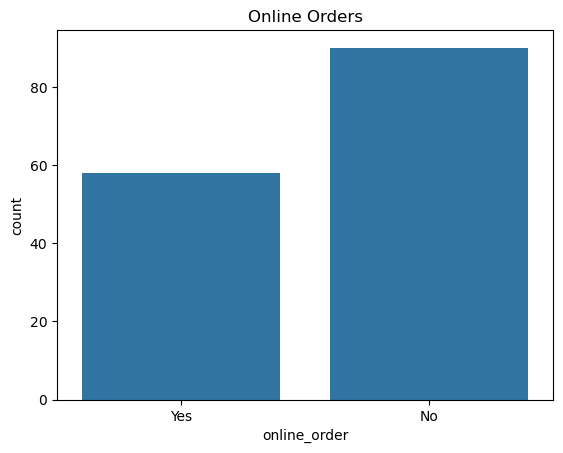

In [ ]:
sns.countplot(x='online_order', data=df)
plt.title('Online Orders')
plt.show()

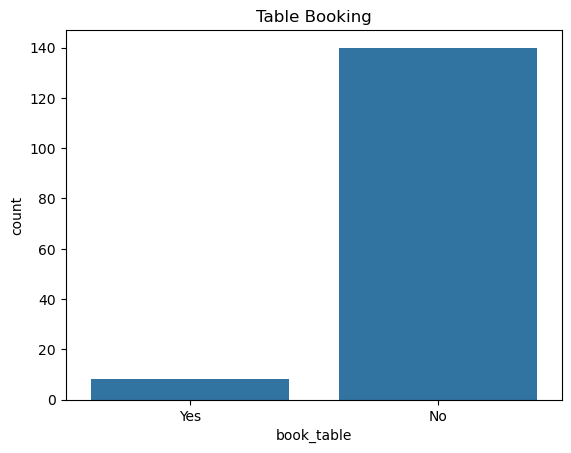

In [ ]:
sns.countplot(x='book_table', data=df)
plt.title('Table Booking')
plt.show()

In [ ]:
# Check duplicate rows
print("Duplicate Rows =", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

Duplicate Rows = 0


In [ ]:
print("Total Restaurants =", len(df))

Total Restaurants = 148


In [ ]:
df['listed_in(type)'].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

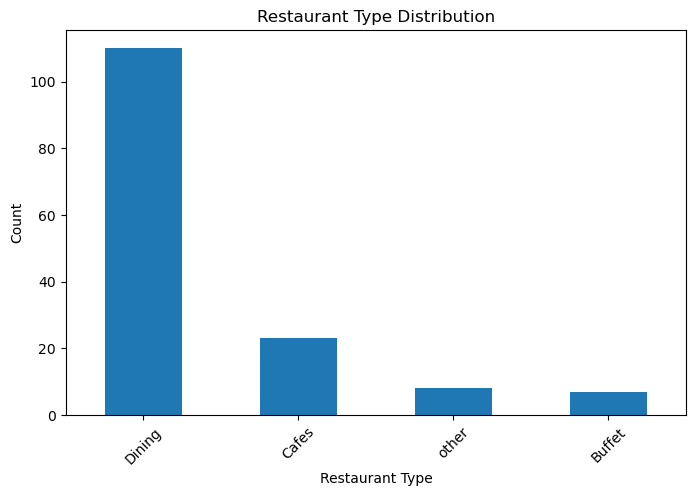

In [ ]:
restaurant_type = df['listed_in(type)'].value_counts()

plt.figure(figsize=(8,5))
restaurant_type.plot(kind='bar')

plt.title("Restaurant Type Distribution")
plt.xlabel("Restaurant Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [ ]:
df['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

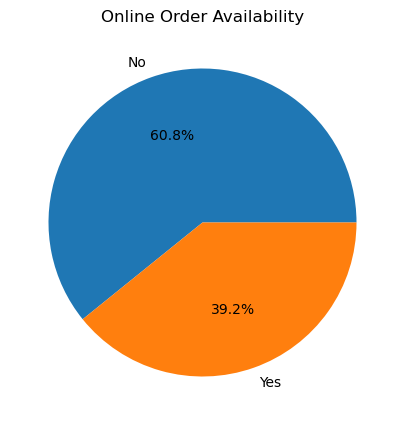

In [ ]:
online = df['online_order'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    online,
    labels=online.index,
    autopct="%1.1f%%"
)

plt.title("Online Order Availability")
plt.show()

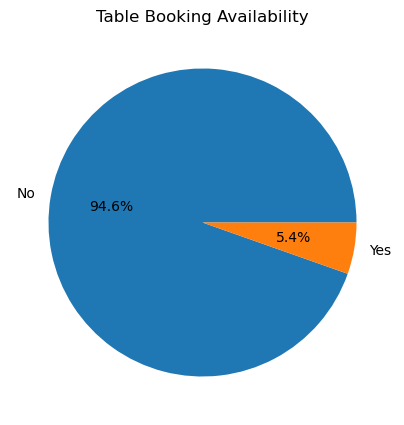

In [ ]:
booking = df['book_table'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    booking,
    labels=booking.index,
    autopct="%1.1f%%"
)

plt.title("Table Booking Availability")
plt.show()

In [ ]:
df = df.sort_values(by='rate', ascending=False)

df[['name','rate']].head(10)

,name,rate
44,Onesta,4.6/5
7,Onesta,4.6/5
38,Empire Restaurant,4.4/5
86,Meghana Foods,4.4/5
52,Corner House Ice Cream,4.3/5
37,Szechuan Dragon,4.2/5
60,Peppy Peppers,4.2/5
81,Frozen Bottle,4.2/5
12,The Coffee Shack,4.2/5
11,Cafe Shuffle,4.2/5


In [ ]:
top_votes = df.sort_values(by='votes', ascending=False)

top_votes[['name','votes']].head(10)

,name,votes
38,Empire Restaurant,4884
86,Meghana Foods,4401
44,Onesta,2556
7,Onesta,2556
65,Kabab Magic,1720
37,Szechuan Dragon,1647
54,Roving Feast,1047
14,San Churro Cafe,918
2,San Churro Cafe,918
67,Gustoes Beer House,868


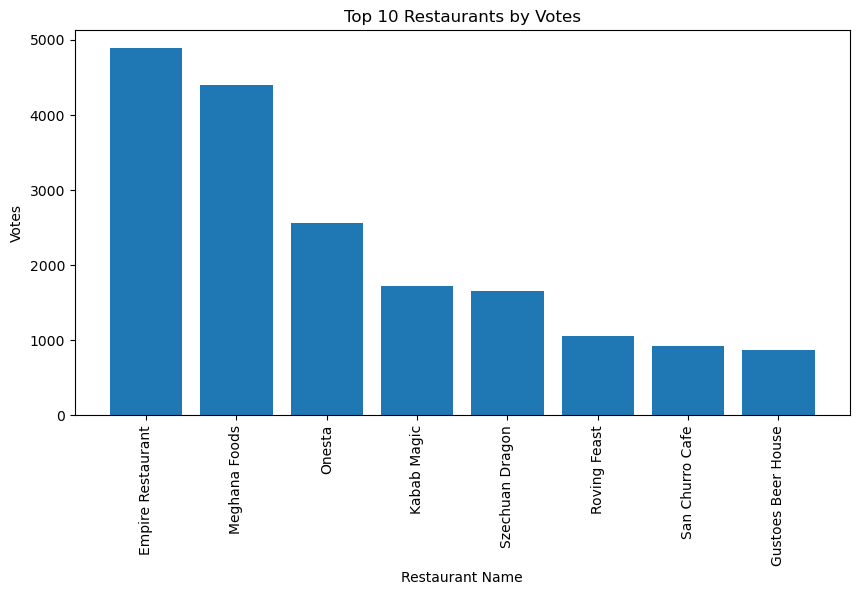

In [ ]:
top10 = df.sort_values(by='votes', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['name'], top10['votes'])

plt.xticks(rotation=90)
plt.title("Top 10 Restaurants by Votes")
plt.xlabel("Restaurant Name")
plt.ylabel("Votes")

plt.show()

In [ ]:
average_cost = df['approx_cost(for two people)'].mean()

print("Average Cost for Two People =", round(average_cost,2))

Average Cost for Two People = 418.24


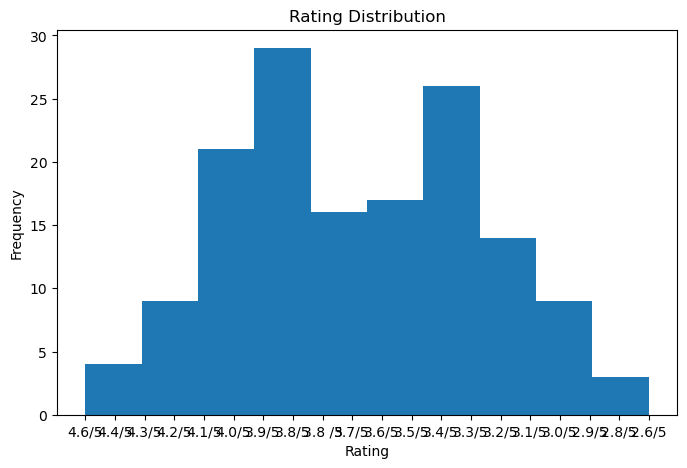

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['rate'], bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

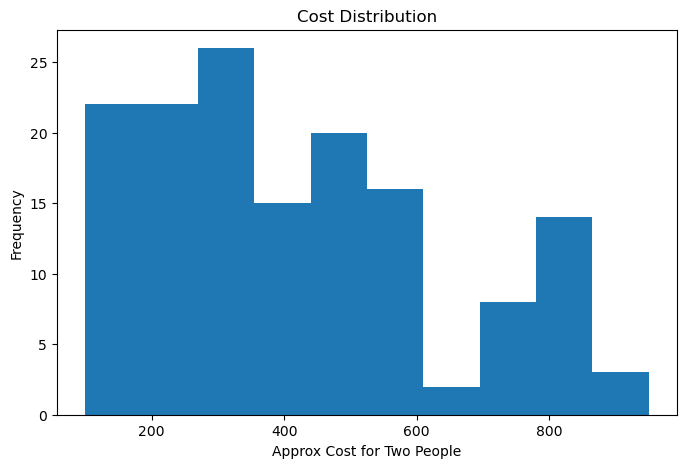

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df['approx_cost(for two people)'],
    bins=10
)

plt.title("Cost Distribution")
plt.xlabel("Approx Cost for Two People")
plt.ylabel("Frequency")

plt.show()

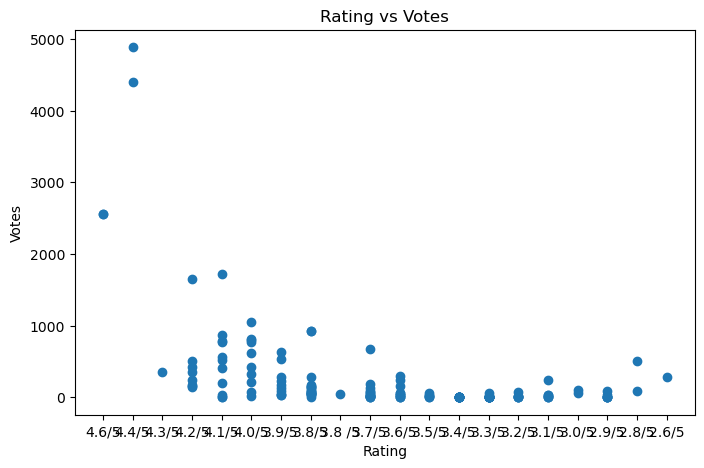

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['rate'],
    df['votes']
)

plt.xlabel("Rating")
plt.ylabel("Votes")
plt.title("Rating vs Votes")

plt.show()

In [ ]:
highest_rated = df.loc[df['rate'].idxmax()]

print(highest_rated)

name                           Onesta
online_order                      Yes
book_table                        Yes
rate                            4.6/5
votes                            2556
approx_cost(for two people)       600
listed_in(type)                 other
Name: 44, dtype: object


In [ ]:
highest_votes = df.loc[df['votes'].idxmax()]

print(highest_votes)

name                           Empire Restaurant
online_order                                 Yes
book_table                                    No
rate                                       4.4/5
votes                                       4884
approx_cost(for two people)                  750
listed_in(type)                            other
Name: 38, dtype: object
